In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import openpyxl

In [2]:
df = pd.read_excel('LogoComparisonData.xlsx')

In [3]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0


## Text Similarity Issue
For this test Text Similarity Score ended up being a way better indicator than it usually is because name of original logo is in the title of the counterfeit. I decided to use Text Similarity being 100 as an indicator of a logo match. Although I'm sure it's not precise, it's just what I did for this first analysis. I created a column called 'match' and made the entries True if text similarity is 100, False otherwise.

For the next test I will prevent the code from comparing a counterfeit's name to anything since it's a giveaway. Then we can incorporate text similarity into the classification. Right now it's not playing a part.

In [4]:
def hundred2true(num):
    return num==100

df['Match'] = df['Text Similarity Score'].apply(hundred2true)


## Now check that all the data are present and the right type

In [5]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Applicant Logo          14274 non-null  object 
 1   Previous Logo           14274 non-null  object 
 2   SSIM                    14274 non-null  float64
 3   Color Similarity Score  14274 non-null  float64
 4   Shape Complexity Score  14274 non-null  float64
 5   Template Matching       14274 non-null  float64
 6   Text Similarity Score   14274 non-null  int64  
 7   Match                   14274 non-null  bool   
dtypes: bool(1), float64(4), int64(1), object(2)
memory usage: 794.7+ KB


In [7]:
#checking for null values
df.isnull().sum()

Applicant Logo            0
Previous Logo             0
SSIM                      0
Color Similarity Score    0
Shape Complexity Score    0
Template Matching         0
Text Similarity Score     0
Match                     0
dtype: int64

# Data visualization

In [8]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


## Obviously the data are super imbalanced. What's the expected rate of fraud in future logos? Does it matter?

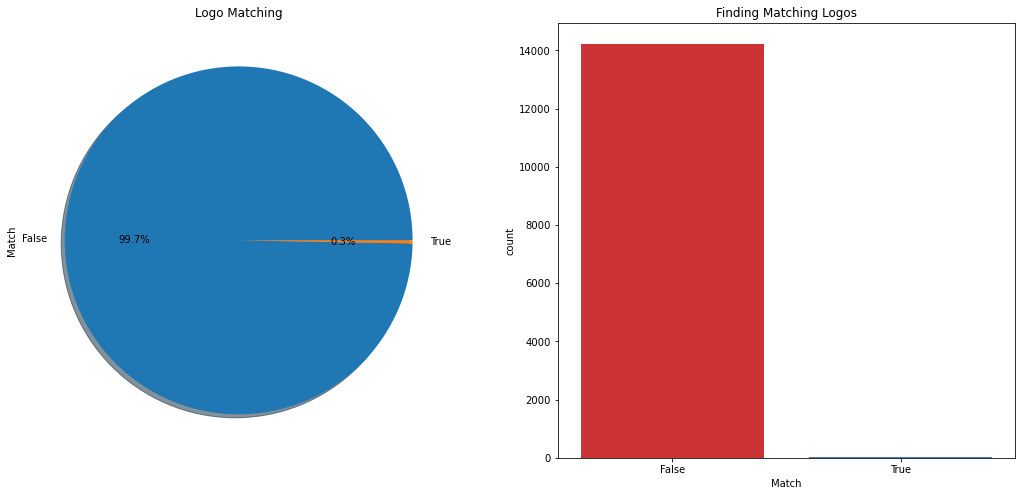

In [9]:
f,ax=plt.subplots(1,2,figsize=(18,8))

ax[0] = df['Match'].value_counts().plot.pie(explode=[0,0],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Logo Matching')


#f, ax = plt.subplots(figsize=(6, 8))
ax[1] = sns.countplot(x="Match", data=df, palette="Set1")
ax[1].set_title("Finding Matching Logos")

plt.show()

In [10]:
df['Match'].value_counts()/len(df)

False    0.997058
True     0.002942
Name: Match, dtype: float64

In [11]:
is_a_match = df[df['Match'] == True]
not_a_match = df[df['Match'] == False]
print ("There are", is_a_match.shape[0], "matches among",  not_a_match.shape[0], "original logos")

There are 42 matches among 14232 original logos


Since it is highy imbalanced  the machine learning algorithm we use may get biased. It would underpredict the minority, which is exactly the opposite of what we're trying to do. We will try to balance this dataset later .

Now let's visualize the average similarity scores for matching and non matching logo comparisons

In [12]:
# Group together the approved logos and the flagged logos
grouped = df.groupby('Match').mean(numeric_only=True)

# Change index from boolean to meaning
grouped = grouped.rename(index = {True: 'Flagged', False: 'Approved'})

# Make every score on a scale from 0-100
grouped['SSIM'] *= 100
grouped['Shape Complexity Score'] *= 100
grouped['Template Matching'] *= 100
grouped

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score
Match,,,,,
Approved,32.117423,32.426337,82.107874,12.900270,26.206225
Flagged,49.818505,22.437657,87.402491,12.955371,100.000000


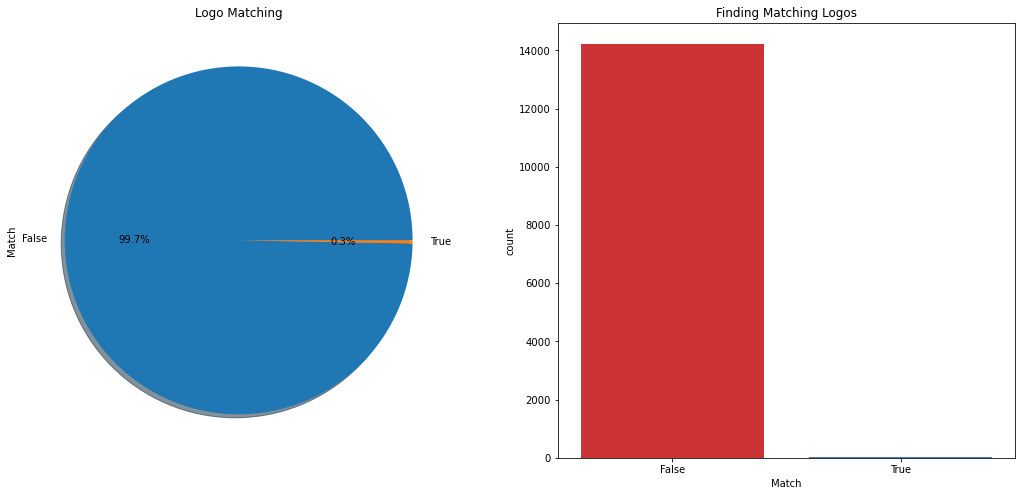

In [13]:
f,ax=plt.subplots(1,2,figsize=(18,8))

ax[0] = df['Match'].value_counts().plot.pie(explode=[0,0],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Logo Matching')


#f, ax = plt.subplots(figsize=(6, 8))
ax[1] = sns.countplot(x="Match", data=df, palette="Set1")
ax[1].set_title("Finding Matching Logos")

plt.show()

In [16]:
grouped

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score
Match,,,,,
Approved,32.117423,32.426337,82.107874,12.900270,26.206225
Flagged,49.818505,22.437657,87.402491,12.955371,100.000000


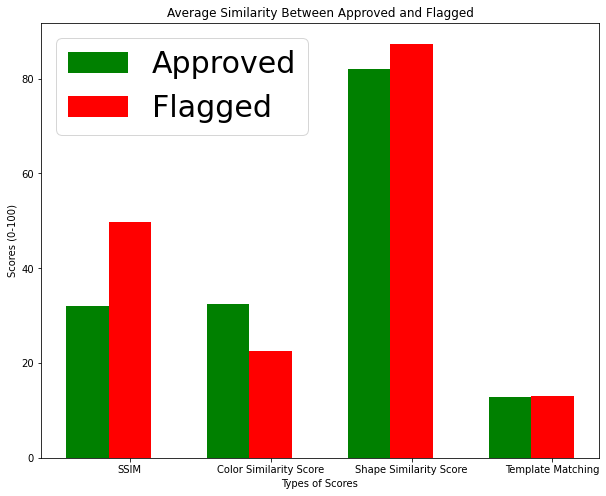

In [18]:
ind = np.arange(4)  
width = 0.3

plt.figure(figsize=(10, 8))
  
xvals = grouped.loc['Approved'][:4]
bar1 = plt.bar(ind, xvals, width, color = 'g') 
  
yvals = grouped.loc['Flagged'][:4]
bar2 = plt.bar(ind+width, yvals, width, color='r') 
  
plt.xlabel('Types of Scores') 
plt.ylabel('Scores (0-100)') 
plt.title('Average Similarity Between Approved and Flagged') 
  
plt.xticks(ind+width,['SSIM', 'Color Similarity Score', 'Shape Similarity Score', 'Template Matching']) 
plt.legend( (bar1, bar2), ('Approved', 'Flagged'), loc='upper left', fontsize=30) 
plt.show()

In [19]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,GiorgoArmani DunkinDonuts (fake).png,gucci.png,0.422474,49.788772,0.856932,0.092365,11,False
1,GiorgoArmani DunkinDonuts (fake).png,venus.png,0.363483,43.027191,0.932490,0.124720,17,False
2,GiorgoArmani DunkinDonuts (fake).png,t-mobile.png,0.397332,26.913052,0.873433,0.132396,16,False
3,GiorgoArmani DunkinDonuts (fake).png,drpepper.png,0.315049,17.180655,0.876244,0.118946,16,False
4,GiorgoArmani DunkinDonuts (fake).png,lv.png,0.378743,38.462226,0.859287,0.119022,0,False


We see people who have done masters are earning less than students who have just cleared their high school which is not normal. Let's try to observe more on these people

### Checking the individual similarity scores for outliers

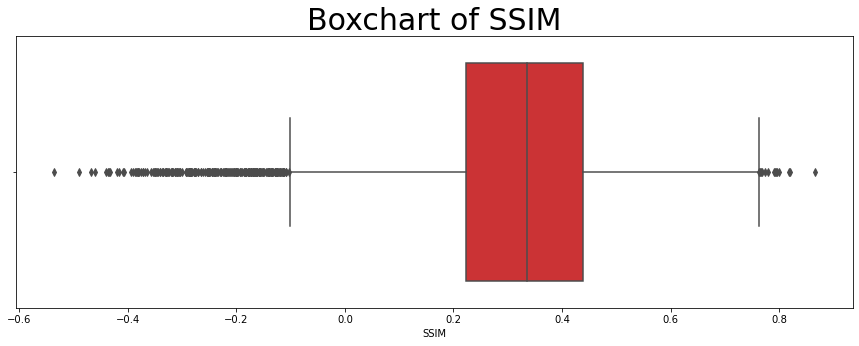

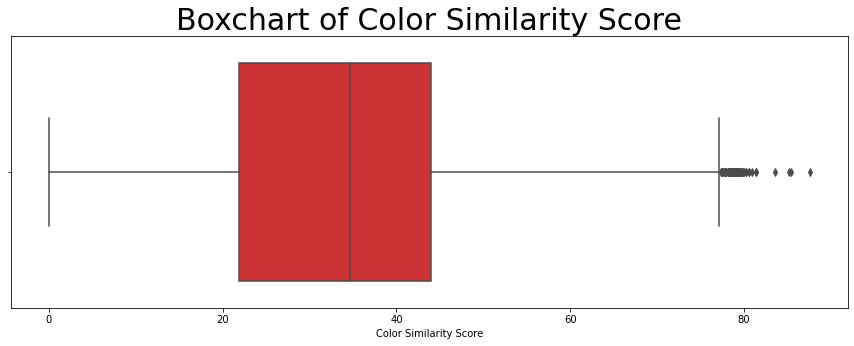

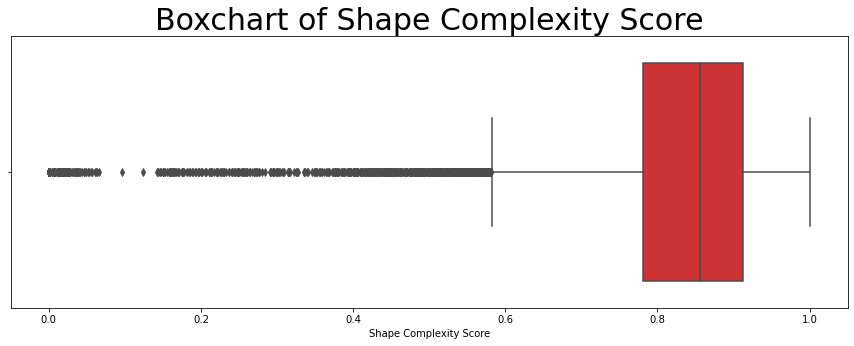

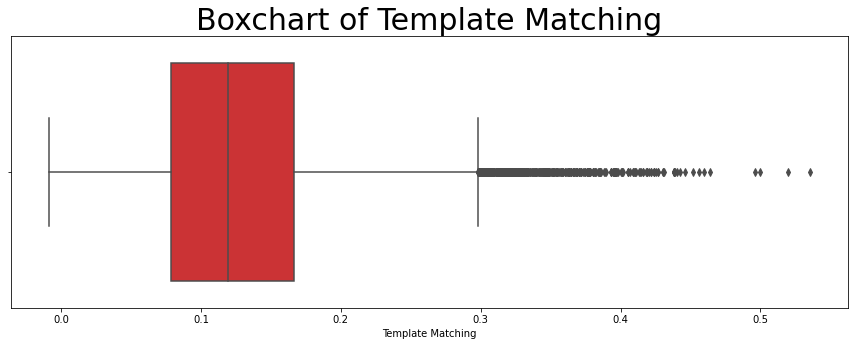

In [19]:
features = ['SSIM', 'Color Similarity Score', 'Shape Complexity Score', 'Template Matching']

for i in numerical:
    plt.figure(figsize=[15, 5])
    sns.boxplot(x = df[i][1:],data=df.iloc[1:], order=df[i][1:].value_counts().index, palette='Set1')
    plt.title("Boxchart of {}".format(i), fontsize=30)
    plt.show()


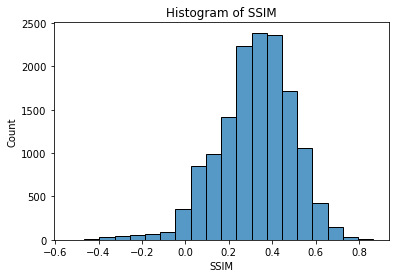

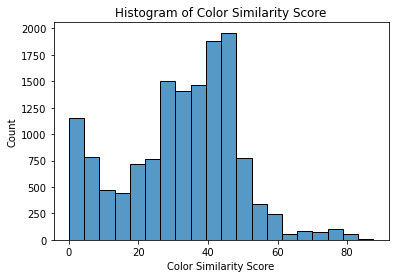

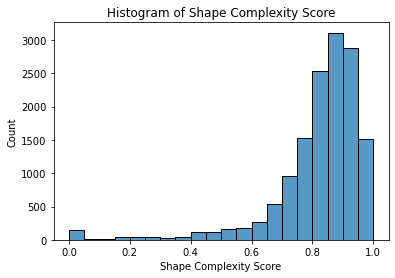

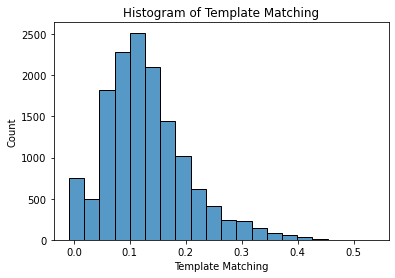

In [20]:
for i in features:
    sns.histplot(x=df[i], palette='Set1',bins=20)
    plt.title("Histogram of {}".format(i))
    plt.show()


In [21]:
distributions = df.copy()[['SSIM', 'Color Similarity Score', 'Shape Complexity Score', 'Template Matching', 'Match']]
distributions

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Match
0,0.422474,49.788772,0.856932,0.092365,False
1,0.363483,43.027191,0.932490,0.124720,False
2,0.397332,26.913052,0.873433,0.132396,False
3,0.315049,17.180655,0.876244,0.118946,False
4,0.378743,38.462226,0.859287,0.119022,False
...,...,...,...,...,...
14269,0.542770,24.406560,0.902102,0.098706,False
14270,0.592169,18.731523,0.901187,0.074972,False
14271,0.667509,24.107286,0.863101,0.081106,False
14272,0.603062,4.633276,0.875855,0.093654,False


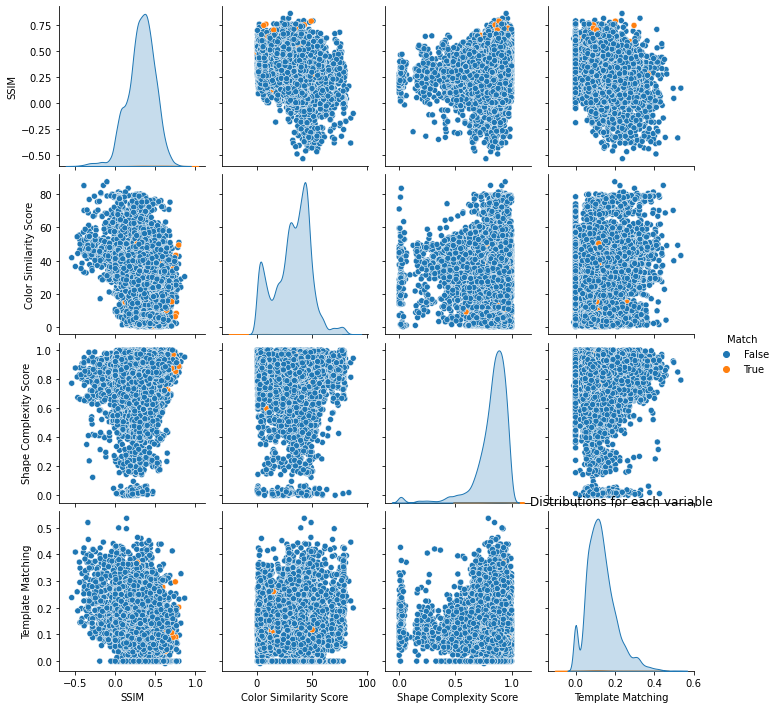

In [22]:
sns.pairplot(data=distributions, hue='Match')
plt.title('Distributions for each variable')
plt.show()

# Label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
def label_encoder(a):
    le = LabelEncoder()
    df[a] = le.fit_transform(df[a])

In [25]:
df.columns

Index(['Applicant Logo', 'Previous Logo', 'SSIM', 'Color Similarity Score',
       'Shape Complexity Score', 'Template Matching', 'Text Similarity Score',
       'Match'],
      dtype='object')

In [26]:
label_list = df.columns
for i in label_list:
    label_encoder(i)

In [27]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,5,163,10178,10060,7172,3973,6,0
1,5,360,8113,7892,11843,6925,12,0
2,5,329,9354,3348,8182,7589,11,0
3,5,137,6435,1981,8362,6372,11,0
4,5,217,8663,6397,7311,6379,0,0


# Normalizing the variables 

In [28]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
scaler = MinMaxScaler()

In [30]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,5,163,10178,10060,7172,3973,6,0
1,5,360,8113,7892,11843,6925,12,0
2,5,329,9354,3348,8182,7589,11,0
3,5,137,6435,1981,8362,6372,11,0
4,5,217,8663,6397,7311,6379,0,0


In [31]:
scaler.fit(df.drop(['Applicant Logo','Previous Logo', 'Text Similarity Score', 'Match'],axis=1))

MinMaxScaler()

In [32]:
scaled_features = scaler.transform(df.drop(['Applicant Logo','Previous Logo', 'Text Similarity Score', 'Match'],axis=1))

In [33]:
# Numeric columns
columns=list(df.columns.values)[2:-2]
columns

['SSIM',
 'Color Similarity Score',
 'Shape Complexity Score',
 'Template Matching']

In [34]:
df_scaled = pd.DataFrame(scaled_features,columns=columns)
df_scaled.head()

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching
0,0.713095,0.899017,0.505106,0.295962
1,0.568416,0.705273,0.834073,0.515867
2,0.655363,0.299196,0.576238,0.565331
3,0.450851,0.177033,0.588915,0.474672
4,0.606950,0.571671,0.514895,0.475194


# Handling Imbalanced dataset

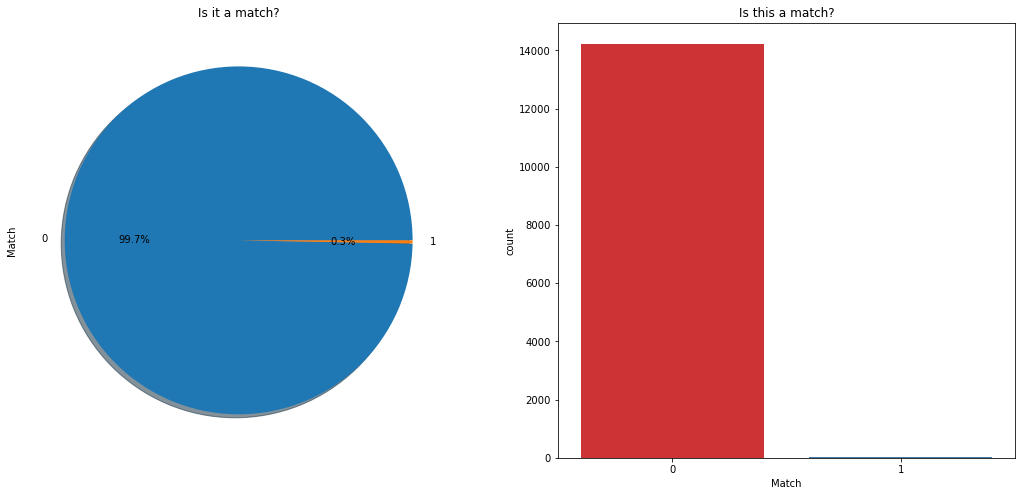

In [37]:
f,ax=plt.subplots(1,2,figsize=(18,8))

ax[0] = df['Match'].value_counts().plot.pie(explode=[0,0],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Is it a match?')


#f, ax = plt.subplots(figsize=(6, 8))
ax[1] = sns.countplot(x="Match", data=df, palette="Set1")
ax[1].set_title("Is this a match?")

plt.show()

### Using over sampling method to handle imbalanced dataset

In [38]:
df.head()

,Applicant Logo,Previous Logo,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching,Text Similarity Score,Match
0,5,163,10178,10060,7172,3973,6,0
1,5,360,8113,7892,11843,6925,12,0
2,5,329,9354,3348,8182,7589,11,0
3,5,137,6435,1981,8362,6372,11,0
4,5,217,8663,6397,7311,6379,0,0


In [39]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import NearMiss

In [40]:
X = df_scaled
y= df.Match
X

,SSIM,Color Similarity Score,Shape Complexity Score,Template Matching
0,0.713095,0.899017,0.505106,0.295962
1,0.568416,0.705273,0.834073,0.515867
2,0.655363,0.299196,0.576238,0.565331
3,0.450851,0.177033,0.588915,0.474672
4,0.606950,0.571671,0.514895,0.475194
...,...,...,...,...
14269,0.917747,0.260858,0.702303,0.336785
14270,0.960695,0.191957,0.698077,0.188915
14271,0.989421,0.256479,0.532432,0.224449
14272,0.966230,0.051117,0.587224,0.304678


In [41]:
# Implementing Oversampling for Handling Imbalanced 
smk = SMOTETomek(random_state=42)
X_res,y_res=smk.fit_resample(X,y)

In [42]:
X_res.shape,y_res.shape

((28456, 4), (28456,))

In [43]:
from collections import Counter
print('Original dataset shape {}'.format(Counter(y)))
print('Resampled dataset shape {}'.format(Counter(y_res)))

Original dataset shape Counter({0: 14232, 1: 42})
Resampled dataset shape Counter({0: 14228, 1: 14228})


# Split the data into training and testing sets

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.20,random_state=101,shuffle=True)

In [46]:
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (22764, 4)
X_test shape: (5692, 4)
y_train shape: (22764,)
y_test shape: (5692,)


In [47]:
# To store results of models
result_dict_train = {}
result_dict_test = {}

# Building Models

## Gradient Boosting

In [277]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

CPU times: user 24 µs, sys: 2 µs, total: 26 µs
Wall time: 56.7 µs


In [279]:
%%time
gradient_booster = GradientBoostingClassifier(learning_rate=0.1)
accuracies = cross_val_score(gradient_booster, X_train, y_train, cv=5)
gradient_booster.fit(X_train,y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",gradient_booster.score(X_test,y_test))

Train Score: 0.75394328264107
Test Score: 0.7568238213399504
CPU times: user 23.5 s, sys: 28.4 ms, total: 23.5 s
Wall time: 23.5 s


In [280]:
result_dict_train["Gradient-Boost Default Train Score"] = np.mean(accuracies)
result_dict_test["Gradient-Boost Default Test Score"] = gradient_booster.score(X_test,y_test)

CPU times: user 11.3 ms, sys: 2.88 ms, total: 14.2 ms
Wall time: 12.4 ms


In [281]:
%%time
grid = {
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':np.arange(100,500,100),
}

gb = GradientBoostingClassifier()
gb_cv = GridSearchCV(gb, grid, cv = 4)
gb_cv.fit(X_train,y_train)
print("Best Parameters:",gb_cv.best_params_)
print("Train Score:",gb_cv.best_score_)
print("Test Score:",gb_cv.score(X_test,y_test))

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 400}
Train Score: 0.8360953562566465
Test Score: 0.837646224742999
CPU times: user 7min 17s, sys: 256 ms, total: 7min 17s
Wall time: 7min 17s


In [287]:
result_dict_train["Gradient-Boost GridSearch Train Score"] = gb_cv.best_score_
result_dict_test["Gradient-Boost GridSearch Test Score"] = gb_cv.score(X_test,y_test)

CPU times: user 86.1 ms, sys: 79 µs, total: 86.2 ms
Wall time: 84.2 ms


# SVC

In [288]:
%%time
from sklearn.svm import SVC
svc = SVC(random_state = 101)
accuracies = cross_val_score(svc, X_train, y_train, cv=5)
svc.fit(X_train,y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",svc.score(X_test,y_test))

Train Score: 0.6894718069916859
Test Score: 0.7008153137185396
CPU times: user 1min 40s, sys: 349 ms, total: 1min 40s
Wall time: 1min 40s


In [289]:
%%time
result_dict_train["SVM Default Train Score"] = np.mean(accuracies)
result_dict_test["SVM Default Test Score"] = svc.score(X_test,y_test)

CPU times: user 4.4 s, sys: 4.03 ms, total: 4.41 s
Wall time: 4.4 s


In [48]:
# ### WARNING! Long Runtime ###

# grid = {
#     'C':[0.01,0.1,1,10],
#     'kernel' : ["linear","poly","rbf","sigmoid"],
#     'degree' : [1,3,5,7],
#     'gamma' : [0.01,1]
# }

# svm  = SVC ()
# svm_cv = GridSearchCV(svm, grid, cv = 5)
# svm_cv.fit(X_train,y_train)
# print("Best Parameters:",svm_cv.best_params_)
# print("Train Score:",svm_cv.best_score_)
# print("Test Score:",svm_cv.score(X_test,y_test))

# Naive Bayes

In [293]:
%%time
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
accuracies = cross_val_score(classifier, X_train, y_train, cv=5)
classifier.fit(X_train, y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",classifier.score(X_test,y_test))

Train Score: 0.6279244197901773
Test Score: 0.6348812477844736
CPU times: user 98.7 ms, sys: 4.11 ms, total: 103 ms
Wall time: 100 ms


In [294]:
%%time
result_dict_train["Naive Bayes Default Train Score"] = np.mean(accuracies)
result_dict_test["Naive Bayes Default Test Score"] = classifier.score(X_test,y_test)

CPU times: user 7.54 ms, sys: 2.6 ms, total: 10.1 ms
Wall time: 8.02 ms


# Logistic Regression

In [295]:
%%time
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=5000)
accuracies = cross_val_score(lr_model, X_train, y_train, cv=5)
lr_model.fit(X_train, y_train)

print("Train Score:",np.mean(accuracies))
print("Test Score:",lr_model.score(X_test,y_test))

Train Score: 0.5965078484928246
Test Score: 0.5948245303084013
CPU times: user 6.27 s, sys: 56.6 s, total: 1min 2s
Wall time: 30.8 s


In [296]:
%%time
result_dict_train["Logistic regression Default Train Score"] = np.mean(accuracies)
result_dict_test["Logistic regression Default Test Score"] = lr_model.score(X_test,y_test)

CPU times: user 39.8 ms, sys: 357 ms, total: 397 ms
Wall time: 200 ms


In [ ]:
%%time
c_space = np.logspace(-5, 8, 15)
param_grid = {'C': c_space}
  
# Instantiating logistic regression classifier
logreg = LogisticRegression(max_iter=4000)
  
# Instantiating the GridSearchCV object
logreg_cv = GridSearchCV(logreg, param_grid, cv = 5)
logreg_cv.fit(X_train, y_train)

print("Best Parameters:",logreg_cv.best_params_)
print("Train Score:",logreg_cv.best_score_)
print("Test Score:",logreg_cv.score(X_test,y_test))

In [ ]:
result_dict_train["Logistic Regression GridSearch Train Score"] = logreg_cv.best_score_
result_dict_test["Logistic Regression GridSearch Test Score"] = logreg_cv.score(X_test,y_test)

# Decision Tree
Decision tree so far has the most accurate predictions. See below for implementation and visualization.

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn import metrics

In [72]:
%%time
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9771609276177091
CPU times: user 314 ms, sys: 5.29 ms, total: 319 ms
Wall time: 318 ms


In [50]:
# tree_entropy = tree.DecisionTreeClassifier(criterion = 'entropy', 
#                                            random_state = 100, 
#                                            max_depth = 3, 
#                                            min_samples_leaf = 5)


# tree_entropy(X_train, y_train)

In [51]:
## Predicting logo match using decision tree classifier
# match_predictions = tree_entropy.predict(X_test)
# score = accuracy_score(y_test, match_predictions)
# print("Test Score:", score*100)

## Decision Tree Visualization

In [83]:
text_representation = tree.export_text(clf)
print(text_representation)

|--- feature_0 <= 0.34
|   |--- feature_1 <= 0.23
|   |   |--- feature_3 <= 0.77
|   |   |   |--- feature_3 <= 0.69
|   |   |   |   |--- feature_3 <= 0.67
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_3 >  0.67
|   |   |   |   |   |--- feature_0 <= 0.31
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- feature_0 >  0.31
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.69
|   |   |   |   |--- feature_2 <= 0.34
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_2 >  0.34
|   |   |   |   |   |--- feature_2 <= 0.42
|   |   |   |   |   |   |--- feature_0 <= 0.18
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- feature_0 >  0.18
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_2 >  0.42
|   |   |   |   |   |   |--- class: 0
|   |   |--- feature_3 >  0.77
|   |   |   |--- feature_1 <= 0.15
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  0.15
|   |   |   |   |--- feature_2

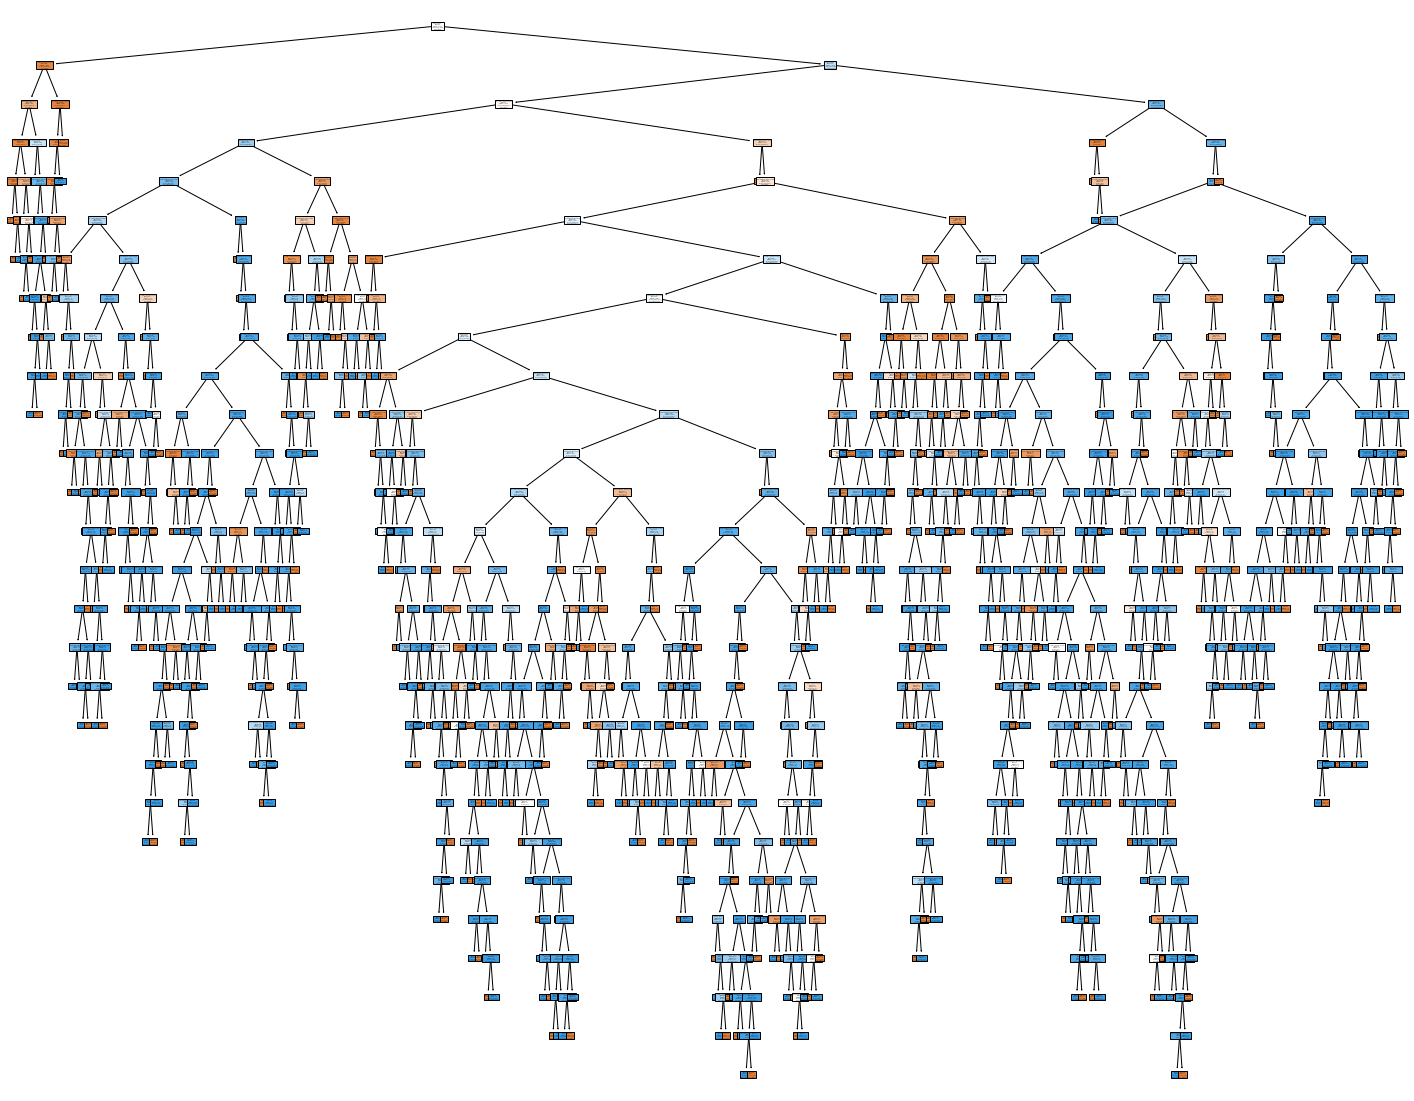

In [88]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(clf, 
                   feature_names=features,  
                   class_names=['Match', 'Not a match'],
                   filled=True)